<div style="text-align: center; padding: 30px 10px;">

<h1 style="color:#ff7500; font-size: 24px; margin-bottom: 10px;">
МФТИ ФПМИ
</h1>

<h2 style="font-size: 30px; margin-top: 5px;">
Практикум Python - Продвинутый Поток
</h2>

<hr style="width: 60%; border: 1px solid #10069f; margin: 25px auto;">

<h3 style="font-size: 36px;">
Лекция 2. Дескрипторы. Метаклассы. __init_subclass__.
</h3>

<p style="margin-top: 20px;">
<strong>Дата:</strong> 07 марта 2026 года<br>
</p>

<p style="margin-top: 25px;">
Данный ноутбук является частью серии семинаров по курсу  
<em>«Практикум Python»</em> и предназначен для учебных и образовательных целей.
</p>

</div>


# Дескрипторы

## Зачем нужны дескрипторы

Мы хотим контролировать доступ к полю (валидация, преобразование, логирование) **одинаково для многих классов**,
не копируя `set_name/set_surname/...`.

Дескриптор — это объект, лежащий в атрибуте *класса*, у которого определены `__get__`, `__set__`, `__delete__`.
Он включается автоматически во время attribute lookup.

Документация:
- https://docs.python.org/3/howto/descriptor.html
- https://docs.python.org/3/howto/descriptor.html#overview-of-descriptor-invocation

`getattr()/setattr()/delattr()` — это API доступа к атрибутам; это не сам протокол дескрипторов.


### Мотивация: копипаст валидации

Сначала делаем валидацию вручную через `set_name`.
Проблема: как только появляется второе поле (`surname`) или второй класс, код начинает дублироваться.


In [ ]:
class Cow:
    def __init__(self, name: str) -> None:
        self._name = name

    def set_name(self, name: str) -> None:
        if not isinstance(name, str):
            raise ValueError(f"Expected type <str> for name, got <{type(name).__name__}>")
        if not name or not name.isalnum():
            raise ValueError("Name should be non-empty alphanumeric string")
        self._name = name


cow = Cow("Isabella")
for value in (1, "", "Ja Ra"):
    try:
        cow.set_name(value)
    except ValueError as e:
        print(e)


Expected type <str> for name, got <int>
Name should be non-empty alphanumeric string
Name should be non-empty alphanumeric string


In [ ]:
class Sheep:
    def __init__(self, name: str) -> None:
        self._name = name

    def set_name(self, name: str) -> None:
        if not isinstance(name, str):
            raise ValueError(f"Expected type <str> for name, got <{type(name).__name__}>")
        if not name or not name.isalnum():
            raise ValueError("Name should be non-empty alphanumeric string")
        self._name = name


## Решения
### Наследование


In [ ]:
class Animal:
    def __init__(self, name: str) -> None:
        self._name = name

    def set_name(self, name: str) -> None:
        if not isinstance(name, str):
            raise ValueError(f"Expected type <str> for name, got <{type(name).__name__}>")
        if not name or not name.isalnum():
            raise ValueError("Name should be non-empty alphanumeric string")
        self._name = name


class Cow(Animal):
    pass


class Sheep(Animal):
    pass


### Почему наследование не решает всё

Наследованием удобно вынести общий `set_name`, но как только в одном из классов появляются дополнительные поля
(например, `surname` у `Farmer`), дублирование возвращается.
Нужна сущность, которую можно переиспользовать на каждом поле, не плодя set_name, set_surname, set_patronymic, … и при этом чтобы она включалась в обычный синтаксис obj.name = ....


In [ ]:
class Farmer(Animal):
    def __init__(self, name: str, surname: str) -> None:
        super().__init__(name)
        self._surname = surname

    def set_surname(self, surname: str) -> None:
        if not isinstance(surname, str):
            raise ValueError(f"Expected type <str> for surname, got <{type(surname).__name__}>")
        if not surname or not surname.isalnum():
            raise ValueError("Surname should be non-empty alphanumeric string")
        self._surname = surname


## Что такое дескриптор

Дескриптор — объект в атрибуте класса, у которого есть `__get__`, `__set__` или `__delete__`.
Срабатывает при доступе к атрибуту через экземпляр/класс, потому что lookup идёт через `__getattribute__`.

Важно: дескриптор вызывается только когда найден как атрибут класса (в `type(obj).__dict__` или по `MRO`), а не как обычное значение в `obj.__dict__`.


### Минимальный дескриптор: видно `instance` и `owner`

- `instance` — объект, через который обращаются (`n.t`)
- `owner` — класс объекта (`Num`)
- если обращение через класс (`Num.t`), то `instance is None`


In [ ]:
class Ten:
    def __get__(self, instance, owner):
        print(f"instance={instance!r}, owner={owner.__name__}")
        return 10


class Num:
    descriptor = Ten()
    


n = Num()
print(n.descriptor)
print(Num.descriptor)


instance=<__main__.Num object at 0x107ff30e0>, owner=Num
10
instance=None, owner=Num
10


In [ ]:
Num.__dict__

mappingproxy({'__module__': '__main__',
              '__firstlineno__': 7,
              'descriptor': <__main__.Ten at 0x107ff3620>,
              '__static_attributes__': (),
              '__dict__': <attribute '__dict__' of 'Num' objects>,
              '__weakref__': <attribute '__weakref__' of 'Num' objects>,
              '__doc__': None})

In [ ]:
n.__dict__

{}

### Ключевой факт

Дескриптор срабатывает только потому, что `descriptor` лежит в `Num.__dict__` как атрибут класса.
Если бы `descriptor` был записан в `n.__dict__`, метод `__get__` не вызывался бы.

**Что происходит при `n.descriptor`:**

```text
n.descriptor
  -> object.__getattribute__(n, "descriptor")
  -> Num.__dict__["descriptor"].__get__(n, Num)
  -> descriptor.__get__(instance=n, owner=Num)
```

Ремарка: `Class.attr` и `obj.attr` могут вести себя по-разному, потому что при доступе через класс
в дескриптор приходит `instance=None`.


## Non-data vs data дескрипторы (самое важное)

- **non-data**: есть только `__get__` -> атрибут экземпляра в `obj.__dict__` может его перекрыть.
- **data**: есть `__set__`/`__delete__` -> дескриптор имеет приоритет над `obj.__dict__`.

Это напрямую объясняет поведение `property` (data descriptor) и `staticmethod` (non-data descriptor).


In [ ]:
class NonData:
    def __get__(self, obj, objtype=None):
        return "from NonData __get__"


class Data:
    def __get__(self, obj, objtype=None):
        return "from Data __get__"

    def __set__(self, obj, value):
        obj.__dict__["d"] = value


class Demo:
    nd = NonData()
    d = Data()


demo = Demo()

demo.nd = "instance value"
print("demo.nd:", demo.nd)  # instance dict wins

demo.d = "instance value"
demo.__dict__["d"] = "attempt override"
print("demo.d:", demo.d)    # data descriptor wins


demo.nd: instance value
demo.d: from Data __get__


## Практический дескриптор: валидация строк

Сделаем дескриптор `NonEmptyString`, который:
- при `obj.name = value` валидирует `value`,
- хранит данные в приватном поле,
- запрещает удаление.

Так мы убираем копипаст: одно правило — много полей и много классов.


In [ ]:
class NonEmptyString:
    def __init__(self, private_name: str):
        self.private_name = private_name

    def __get__(self, instance, owner):
        if instance is None:
            # Если доступ через класс (Farmer.name), instance будет None
            return self
        value = instance.__dict__.get(self.private_name)
        if value is None:
            raise AttributeError(f"{owner.__name__}.{self.private_name[1:]} is not set")
        return value

    def __set__(self, instance, value):
        if not isinstance(value, str):
            raise ValueError(f"Expected type <str> for value, got <{type(value).__name__}>")
        if not value or not value.isalnum():
            raise ValueError("Value should be non-empty alphanumeric string")
        instance.__dict__[self.private_name] = value

    def __delete__(self, instance):
        raise ValueError("Value cannot be deleted")


In [ ]:
class Farmer:
    name = NonEmptyString("_name")
    surname = NonEmptyString("_surname")

    def __init__(self, name: str, surname: str):
        self.name = name
        self.surname = surname


farmer = Farmer("Leo", "Pellegro")
print(farmer.name, farmer.surname)

try:
    farmer.name = ""
except ValueError as e:
    print(e)


Leo Pellegro
Value should be non-empty alphanumeric string


### Улучшение: `__set_name__`, чтобы не передавать имя вручную

Вместо `NonEmptyString("_name")` можно определить `__set_name__(owner, name)`.
Python вызовет его при создании класса и передаст имя атрибута (`name`, `surname`).
Это делает дескриптор самонастраивающимся и уменьшает бойлерплейт(повторяющийся шаблонный код).


In [ ]:
class NonEmptyString2:
    def __set_name__(self, owner, name):
        self.private_name = f"_{name}"

    def __get__(self, instance, owner):
        if instance is None:
            # Если доступ через класс (Farmer.name), instance будет None
            return self
        value = instance.__dict__.get(self.private_name)
        if value is None:
            raise AttributeError(f"{owner.__name__}.{self.private_name[1:]} is not set")
        return value

    def __set__(self, instance, value):
        if not isinstance(value, str):
            raise ValueError(f"Expected type <str> for value, got <{type(value).__name__}>")
        if not value or not value.isalnum():
            raise ValueError("Value should be non-empty alphanumeric string")
        instance.__dict__[self.private_name] = value


class Farmer2:
    name = NonEmptyString2()
    surname = NonEmptyString2()

    def __init__(self, name: str, surname: str):
        self.name = name
        self.surname = surname


farmer2 = Farmer2("Nikolai", "Jos")
print(farmer2.name, farmer2.surname)


## `property`, `staticmethod`, `classmethod` как дескрипторы

- `property` — data descriptor: его нельзя перекрыть одноимённым полем в `obj.__dict__`.
- `staticmethod` — non-data descriptor: его можно перекрыть атрибутом экземпляра.
- `classmethod` — non-data descriptor, возвращающий функцию, привязанную к классу (`cls`).


In [ ]:
class MyClassMethod:
    def __init__(self, func):
        self.func = func

    def __get__(self, instance, owner):
        def bound(*args, **kwargs):
            return self.func(owner, *args, **kwargs)
        return bound


class Cat:
    kind = "cat"

    @MyClassMethod
    def sound(cls):
        return f"{cls.kind}: meow"


print(Cat.sound())
print(Cat().sound())


cat: meow
cat: meow


# Метаклассы

Мы знаем что все в python это объекты, а как известно каждый объект имеет тип:

Для примера рассмотрим класс User

In [ ]:
class User:
    pass

user = User()
print(user)
print(user.__class__)
print(type(user))

<class '__main__.User'>
<class '__main__.User'>


In [ ]:
obj.__class__ возвращает класс (тип) объекта obj — то же самое, что type(obj).

In [2]:
type(user) is user.__class__

True

Посмотрим тип у других объектов, в том числе и встроенных

In [8]:
print(type(4)) # <class 'int'>
print(type(int)) # ???
print(type(dict)) # ???
print(type(User)) # ???
print(type(type)) # ???

<class 'int'>
<class 'type'>
<class 'type'>
<class 'type'>
<class 'type'>


Итого мы получили, что тип класса — это `type`, тип встроенных объектов — тоже `type`.
Но из последнего: `type(type) == <class 'type'>` видно, что `type` — это тоже класс, а значит, и у него есть тип — `type`.


Т.е. каждый класс имеет тип, и этот тип мы будем называть **`metaclass`**.


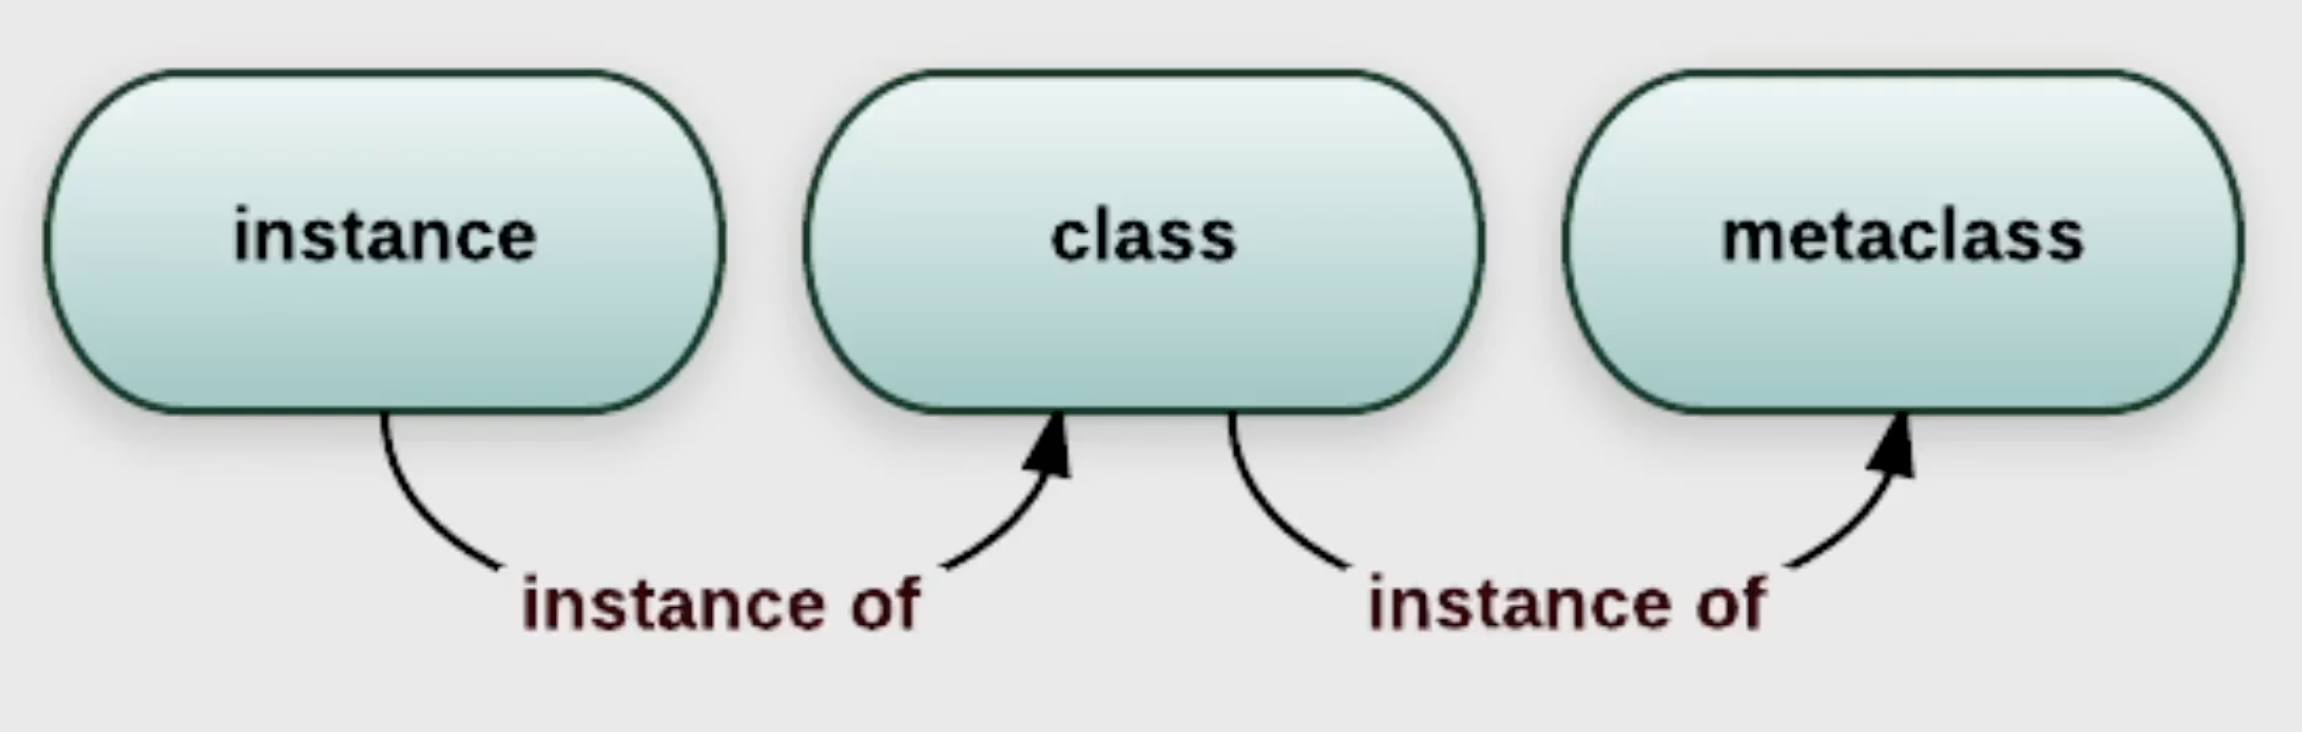


Итого `user` — это экземпляр класса `User`, а целое число — это экземпляр класса `int`.
Но сам класс `int` — это экземпляр типа `type`.
Аналогично, `User`, `dict`, `set` — это экземпляры класса `type`.
В свою очередь, `type` — это экземпляр класса `type`.

Когда мы внедряем метакласс, он встаёт между классом и `type`:
метакласс становится типом для нашего класса, а для метакласса типом уже является `type`.
И для `type` тип всегда `type`.

> Замечание: это утверждение относится к `CPython`/стандартному `Python`; в других реализациях детали могут отличаться.


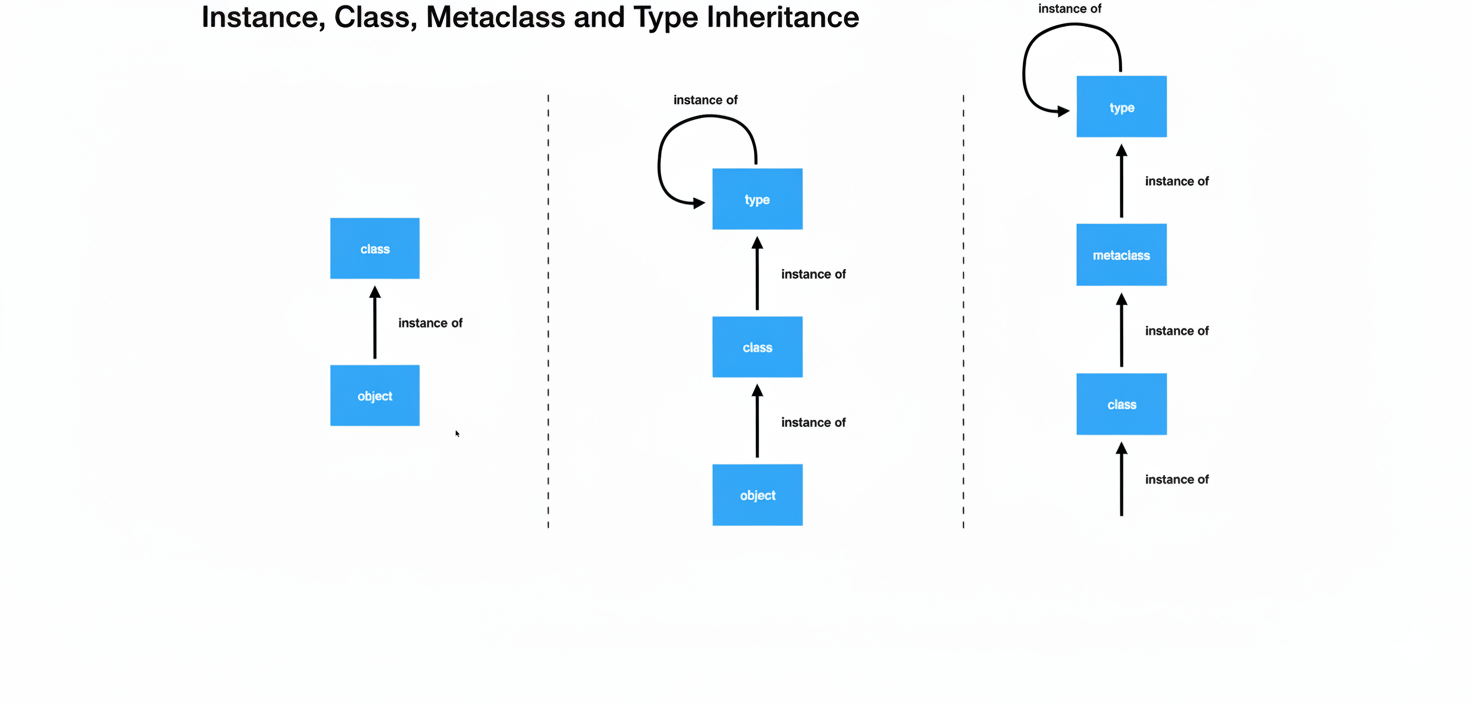

In [9]:
print(help(type))

Help on class type in module builtins:

class type(object)
 |  type(object) -> the object's type
 |  type(name, bases, dict, **kwds) -> a new type
 |
 |  Methods defined here:
 |
 |  __call__(self, /, *args, **kwargs)
 |      Call self as a function.
 |
 |  __delattr__(self, name, /)
 |      Implement delattr(self, name).
 |
 |  __dir__(self, /)
 |      Specialized __dir__ implementation for types.
 |
 |  __getattribute__(self, name, /)
 |      Return getattr(self, name).
 |
 |  __init__(self, /, *args, **kwargs)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  __instancecheck__(self, instance, /)
 |      Check if an object is an instance.
 |
 |  __or__(self, value, /)
 |      Return self|value.
 |
 |  __repr__(self, /)
 |      Return repr(self).
 |
 |  __ror__(self, value, /)
 |      Return value|self.
 |
 |  __setattr__(self, name, value, /)
 |      Implement setattr(self, name, value).
 |
 |  __sizeof__(self, /)
 |      Return memory consumption of the t

Заметим, что мы умеем создавать **сами классы**!

In [ ]:
# A = type(name, bases, dict, **kwds)

A = type("A", (), {"b": 5})

print(A)
a = A()
print(a)
print(a.b)

<class '__main__.A'>
5


Итого мы получили тот же самый объект `user`.


In [10]:
User = type("User", (), {})

user = User()

print(user)
print(user.__class__)
print(type(user))

<class '__main__.User'>
<class '__main__.User'>


Итого мы получили того же самого user

А как с наследованием?

In [59]:
class UserBase:
    foo = "bar"

class User(UserBase):
    spam = "eggs"


user = User()
print(user)
print(user.foo)
print(user.spam)
print(User.mro())

bar
eggs
[<class '__main__.User'>, <class '__main__.UserBase'>, <class 'object'>]


In [60]:
User = type("User", (UserBase, ), {"spam": "eggs"})

user = User()
print(user)
print(user.foo)
print(user.spam)
print(User.mro())

bar
eggs
[<class '__main__.User'>, <class '__main__.UserBase'>, <class 'object'>]


все совпало

Рассмотрим новый класс `User`


In [64]:
class User:
    first_name = ""
    last_name = ""

    def get_full_name(self):
        return f"{self.first_name} {self.last_name}".strip()


user = User()
print(user)
user.first_name = "John"
user.last_name = "Smith"
print(user.get_full_name())

John Smith


In [62]:
vars(User)

mappingproxy({'__module__': '__main__',
              '__firstlineno__': 1,
              'first_name': '',
              'last_name': '',
              'get_full_name': <function __main__.User.get_full_name(self)>,
              '__static_attributes__': (),
              '__dict__': <attribute '__dict__' of 'User' objects>,
              '__weakref__': <attribute '__weakref__' of 'User' objects>,
              '__doc__': None})

In [63]:
help(vars)

Help on built-in function vars in module builtins:

vars(...)
    vars([object]) -> dictionary

    Without arguments, equivalent to locals().
    With an argument, equivalent to object.__dict__.



Создадим аналогичный класс через **`type`**


In [66]:
def get_full_name(user):
    return f"{user.first_name} {user.last_name}".strip()


User = type(
    "User",
    (),
    {
        "first_name": "",
        "last_name": "",
        "get_full_name": get_full_name,
    },
)

user = User()
print(user)
user.first_name = "John"
user.last_name = "Smith"
print(user.get_full_name())

John Smith


In [67]:
vars(User)

mappingproxy({'first_name': '',
              'last_name': '',
              'get_full_name': <function __main__.get_full_name(user)>,
              '__module__': '__main__',
              '__dict__': <attribute '__dict__' of 'User' objects>,
              '__weakref__': <attribute '__weakref__' of 'User' objects>,
              '__doc__': None})

Обратим внимание: здесь `get_full_name` — это не метод класса, а функция модуля, записанная в атрибут класса.


`User.__dict__` возвращает `mappingproxy`.

`mappingproxy` — это read-only представление словаря атрибутов класса:
- читать можно: `User.__dict__['attr']`;
- менять напрямую нельзя: `User.__dict__['attr'] = 1` вызовет ошибку.

Изменять атрибуты класса нужно обычным присваиванием:
```python
User.attr = 1
```


In [73]:
class User:
    def __new__(cls):
        u = super().__new__(cls)
        u.first_name = ""
        u.last_name = ""
        return u

In [74]:
vars(User)

mappingproxy({'__module__': '__main__',
              '__firstlineno__': 1,
              '__new__': <staticmethod(<function User.__new__ at 0x107f5ff60>)>,
              '__static_attributes__': (),
              '__dict__': <attribute '__dict__' of 'User' objects>,
              '__weakref__': <attribute '__weakref__' of 'User' objects>,
              '__doc__': None})

In [75]:
user = User()
vars(user)

{'first_name': '', 'last_name': ''}

### Пример: `__new__` может вернуть объект другого класса (и вести реестр созданных объектов)

Здесь `FamilyMember` выглядит как обычный класс, но его `__new__` устроен так, что при вызове `FamilyMember(Child)` он **не создаёт** экземпляр `FamilyMember`. Вместо этого он создаёт экземпляр того класса, который мы передали аргументом (`Child` или `Parent`), и возвращает именно его.

- `other_type` — это класс, объект которого мы хотим получить.
- `instance = super().__new__(other_type)` — создаём “сырой” экземпляр класса `other_type`.
- `cls._registry.append(instance)` — сохраняем созданный объект в реестре на уровне класса `FamilyMember`.
- `return instance` — возвращаем наружу не `FamilyMember`, а созданный `Child`/`Parent`.

В результате:
- `child = FamilyMember(Child)` даёт объект типа `Child`, поэтому `type(child) is Child`.
- `child.attr == "child"`, аналогично для `Parent`.
- В `FamilyMember._registry` накапливаются все объекты, созданные через этот механизм.

In [79]:
class Parent:
    attr = "parent"

class Child:
    attr = "child"

class FamilyMember:
    _registry = []

    def __new__(cls, other_type):
        instance = super().__new__(other_type)
        cls._registry.append(instance)
        return instance 

In [80]:
child = FamilyMember(Child)
print(child)
print(child.attr)

child


In [81]:
FamilyMember._registry

In [82]:
print(type(child))

<class '__main__.Child'>


In [84]:
parent = FamilyMember(Parent)
print(parent)
print(parent.attr)
print(type(parent))

parent
<class '__main__.Parent'>


In [85]:
FamilyMember._registry

### Пример: метакласс как “тип для классов” (хук на момент создания класса)

`Meta` — это **метакласс**: класс, который создаёт другие классы. Поэтому он наследуется от `type`.

Когда Python выполняет:
```python
class A(metaclass=Meta): ...
он создаёт объект-класс A через Meta, и при этом вызывает Meta.__init__. Поэтому Meta.__init__ срабатывает на этапе создания класса, а не на этапе создания экземпляра.

Ключевые моменты:
	•	cls внутри Meta.__init__ — это создаваемый класс (A, B, …), а не экземпляр.
	•	Строка cls.spam = "eggs" добавляет атрибут каждому классу, созданному этим метаклассом.

Проверки, показывающие модель:
	•	type(A) вернёт Meta, то есть A — экземпляр метакласса Meta.
	•	A.__mro__ / A.mro() — это порядок наследования класса A (обычно A -> object); метакласс туда не входит, потому что метакласс — это “тип класса”, а не “родительский класс”.

После создания классов атрибуты можно переопределять независимо:
A.spam = "foo", B.spam = "bar" — это разные значения у разных классов.

In [24]:
class Meta(type):
    def __init__(cls, name, *args, **kw):
        cls.spam = "eggs"

In [25]:
class A(metaclass=Meta):
    pass

class B(metaclass=Meta):
    pass

print(A.spam)
print(B.spam)

eggs
eggs


In [26]:
A.__mro__

(__main__.A, object)

In [27]:
A.mro()

[__main__.A, object]

In [28]:
type(A)

__main__.Meta

In [29]:
A.spam = "foo"
B.spam = "bar"
print(A.spam)
print(B.spam)

foo
bar


### Пример
### А зачем нам это?
Потому что для **неизменяемых** (immutable) типов вроде `tuple` изменить содержимое “после создания” нельзя. Значит, если мы хотим гарантировать инвариант (например, “все имена в нижнем регистре”), то делать это нужно **до** появления объекта — на этапе `__new__`, а не в `__init__`.

### Создаём имена с нижним регистром:

In [30]:
class UsernamesTuple(tuple):
    def __init__(self, iterable):
        print("init cls w/", iterable)
        print("self", self)

### Почему `__init__` не подходит
Этот вывод показывает ключевую вещь: в `__init__` параметр `self` уже является готовым объектом `tuple`.  
А `tuple` неизменяем, поэтому “привести строки к lower()” здесь уже поздно — нужно вмешиваться **до** создания объекта.

In [31]:
UsernamesTuple(["John", "Sam"])

init cls w/ ['John', 'Sam']
self ('John', 'Sam')


('John', 'Sam')

Вывод подтверждает: сначала объект `tuple` уже создан (это и есть `self`), и только потом вызывается `__init__`.  
Поэтому любые попытки “перезаписать содержимое” в `__init__` для `tuple` не сработают.

### Правильный способ для `tuple`: `__new__`
`__new__` вызывается **до** создания экземпляра. Поэтому здесь мы:
1) берём входной `iterable`,
2) нормализуем элементы (делаем `.lower()`),
3) создаём уже “правильный” `tuple` через `super().__new__(cls, ...)`.

Так инвариант “всё lowercase” гарантируется при каждом создании объекта.

In [104]:
class UsernamesTuple(tuple):
    def __new__(cls, iterable):
        lower_strings = (s.lower() for s in iterable)
        return super().__new__(cls, lower_strings)

In [105]:
UsernamesTuple(["John", "Sam"])

('john', 'sam')

Теперь результат — кортеж со строками в нижнем регистре: объект создаётся сразу в нужном виде, без попыток менять его после.

### Проверяем тип и наследование
- `type(usernames)` показывает, что это экземпляр `UsernamesTuple`.
- `type(usernames).mro()` показывает цепочку наследования класса: `UsernamesTuple -> tuple -> object`.

In [106]:
usernames = UsernamesTuple(["John", "Sam"])

print(type(usernames))
print(type(usernames).mro())

<class '__main__.UsernamesTuple'>
[<class '__main__.UsernamesTuple'>, <class 'tuple'>, <class 'object'>]


Идея: на этапе **создания класса** можно перехватить его namespace (словарь атрибутов) и переписать ключи.  
Для этого:
- `camel_to_snake(name)` переводит имя из `CamelCase` в `snake_case`;
- метакласс `CamelToSnakeMeta(type)` переопределяет `__new__` и строит новый словарь `snake_attrs`, где все имена атрибутов уже в `snake_case`;
- затем создаёт класс через `super().__new__(cls, name, bases, snake_attrs)`.

Результат: если в теле класса `User` написать `userName` и `increaseAge`, то реально в классе появятся `user_name` и `increase_age`.

Важно: это **не наследование и не декоратор**, а именно трансформация класса в момент его конструирования — то, ради чего метаклассы обычно и применяют.

In [49]:
def camel_to_snake(name):
    snake_name_chars = []
    # SnakeCase -> snake_case
    for i, char in enumerate(name):
        if char.isupper() and i:
            snake_name_chars.append("_")
        snake_name_chars.append(char.lower())
    return "".join(snake_name_chars)


class CamelToSnakeMeta(type):
    def __new__(cls, name, bases, attrs):
        snake_attrs = {}
        for attr_name, attr_value in attrs.items():
            snake_name = camel_to_snake(attr_name)
            snake_attrs[snake_name] = attr_value
        return super().__new__(cls,  name, bases, snake_attrs) 

In [107]:
class User(metaclass=CamelToSnakeMeta):
    userName = "john"
    age = 20

    def increaseAge(self):
        self.age += 1
 
vars(User)

mappingproxy({'__module__': '__main__',
              '__firstlineno__': 1,
              'user_name': 'john',
              'age': 20,
              'increase_age': <function __main__.User.increaseAge(self)>,
              '__static_attributes__': (),
              '__dict__': <attribute '__dict__' of 'User' objects>,
              '__weakref__': <attribute '__weakref__' of 'User' objects>,
              '__doc__': None})

### Проверка: что реально лежит в `vars(User)`

`vars(User)` возвращает `mappingproxy` — read-only view словаря класса.  
После применения метакласса в этом словаре видно, что:
- `userName` превратился в `user_name`,
- `increaseAge` превратился в `increase_age`,
- остальные служебные поля (`__module__`, `__dict__`, `__weakref__`, …) остались.

Это прямое доказательство, что метакласс переписал namespace **до** создания класса.

In [108]:
user = User()
print(user.user_name)
print(user.age)
user.increase_age()
print(user.age)

john
20
21


### Пример: метакласс-реестр (RegistryMeta)

Иногда хочется, чтобы каждый объявленный класс автоматически попадал в “реестр” (словарь `name -> class`), а также чтобы нельзя было случайно объявить два класса с одним и тем же именем. Это удобно для плагинов, фабрик, ORM-моделей и т.п.

`RegistryMeta` делает это на этапе **создания класса** (в `__new__`):
- проверяет, что имя класса ещё не встречалось;
- создаёт класс через `super().__new__`;
- сохраняет его в `RegistryMeta._registry`.

In [110]:
class RegistryMeta(type):
    _registry = {}

    def __new__(mcs, name, *args, **kwargs):
        if name in mcs._registry:
            raise NameError(f"Class {name} already defined!")
        cls = super().__new__(mcs, name, *args, **kwargs)
        mcs._registry[name] = cls
        return cls

### Проверка: классы автоматически регистрируются

Как только объявляются классы `User` и `Post` с метаклассом `RegistryMeta`, они сразу попадают в `RegistryMeta._registry`. Поэтому печать `RegistryMeta._registry` показывает словарь, где ключи — имена классов, значения — сами объекты-классы.

In [111]:
class User(metaclass=RegistryMeta):
    pass

class Post(metaclass=RegistryMeta):
    pass

RegistryMeta._registry

{'User': __main__.User, 'Post': __main__.Post}

### Защита от повторного объявления класса

Если попытаться объявить `class User(metaclass=RegistryMeta): ...` ещё раз, метакласс перехватит создание и выбросит `NameError`. Это демонстрирует, что контроль происходит **в момент конструирования класса**, ещё до того как класс появится в программе.

In [112]:
class User(metaclass=RegistryMeta):
    spam = "eggs"

NameError: Class User already defined!

### База с метаклассом: наследники тоже автоматически в реестре

Если сделать базовый класс `ModelBase` с метаклассом `RegistryMeta`, то все его наследники (`Manager`, `Client`, …) будут создаваться с тем же метаклассом автоматически (если не переопределять). Поэтому они тоже попадут в `RegistryMeta._registry` без явного указания `metaclass=...` в каждом классе.

In [58]:
class ModelBase(metaclass=RegistryMeta):
    pass

In [42]:
class Manager(ModelBase):
    pass

class Client(ModelBase):
    pass

RegistryMeta._registry

{'User': __main__.User,
 'Post': __main__.Post,
 'ModelBase': __main__.ModelBase,
 'Manager': __main__.Manager,
 'Client': __main__.Client}

### Альтернатива метаклассу: `__init_subclass__`

Часто метакласс не нужен: если задача — выполнить действие при создании **подкласса**, достаточно определить `__init_subclass__` в базовом классе. Этот метод автоматически вызывается каждый раз, когда объявляется новый наследник.

В примере ниже мы передаём параметр `node_pos` прямо в заголовке класса (`class LeftNode(Node, node_pos="left")`) и сохраняем его как атрибут класса `pos`. Это более простой и читаемый способ, чем метакласс, когда нужно настроить подклассы.

In [43]:
class Node:
    def __init_subclass__(cls, node_pos):
        cls.pos = node_pos
        return cls


class LeftNode(Node, node_pos="left"):
    pass


class RightNode(Node, node_pos="right"):
    pass

### Проверяем: атрибуты выставились на уровне классов

`LeftNode.pos` и `RightNode.pos` — это атрибуты **классов**, заданные в момент создания подклассов через `__init_subclass__`.  
MRO при этом остаётся обычным: `RightNode -> Node -> object`.

In [44]:
print(LeftNode.pos)
print(RightNode.pos)

left
right


In [45]:
RightNode.mro()

[__main__.RightNode, __main__.Node, object]

## А если сделать несколько разных метаклассов? Получится ли наследовать?

In [113]:
class AMeta(type):
    def __call__(cls, *args, **kwargs):
        print("It is A Meta!")
        return super().__call__(*args, **kwargs)


class BMeta(type):
    def __call__(cls, *args, **kwargs):
        print("It is B Meta!")
        return super().__call__(*args, **kwargs)

class A(metaclass=AMeta):
    __slots__ = []

class B(metaclass=BMeta):
    __slots__ = []

In [114]:
class C(A):
    __slots__ = ["x"]

    def __init__(self, x):
        self.x = x

In [115]:
c = C(5)
print(c.x)

It is A Meta!
5


In [122]:
class D(A, B):
    __slots__ = ["x"]

    def __init__(self, x):
        self.x = x

TypeError: metaclass conflict: the metaclass of a derived class must be a (non-strict) subclass of the metaclasses of all its bases

**metaclass conflict**

При `class D(A, B): ...` Python обязан выбрать метакласс для нового класса `D`.
Он выбирает *most derived metaclass* среди метаклассов баз (`type(A)`, `type(B)`, ...) и явно указанного `metaclass` (если он есть).
"Most derived" означает: выбранный метакласс должен быть (нестрогим) подклассом всех кандидатов.
Если такого метакласса нет (например, `type(A)=AMeta` и `type(B)=BMeta`, и ни один не подкласс другого), Python не может создать `D` и выбрасывает
`TypeError: metaclass conflict`.

Стандартное исправление — определить комбинированный метакласс, наследующийся от обоих метаклассов (`class ABMeta(AMeta, BMeta): ...`),
и использовать его для `D`.

### Решение конфликта метаклассов

Определяем общий метакласс, который наследуется от `AMeta` и `BMeta`, и явно используем его для `D`.


In [ ]:
class ABMeta(AMeta, BMeta):
    pass


class D(A, B, metaclass=ABMeta):
    __slots__ = ["x"]

    def __init__(self, x):
        self.x = x


d = D(10)
print(d.x)


Singleton через метакласс

Цель: сделать класс, у которого всегда существует **ровно один экземпляр** (например, подключение к БД).
Наивно можно хранить глобальную переменную/кэш, но хочется:
- чтобы правило работало **для всех вызовов `Database()`** автоматически,
- чтобы оно **наследовалось** (если будут подклассы),
- и чтобы логика была централизована.

In [ ]:
# Наивный singleton:
_db_instance = None

class Database:
    def __init__(self):
        print("Initializing database connection")

def get_db():
    global _db_instance
    if _db_instance is None:
        _db_instance = Database()
    return _db_instance

db1 = get_db()
db2 = get_db()
print(db1 is db2)

### Проблема наивного варианта

- Инвариант "один объект" соблюдается **только если все используют `get_db()`**, а не `Database()`.
- Логика singleton размазана снаружи класса.
- Наследование усложняется: для подклассов нужно отдельно думать о кэше и правилах.

In [ ]:
class SingletonMeta(type):
    _instances = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            cls._instances[cls] = super().__call__(*args, **kwargs)
        return cls._instances[cls]

class Database(metaclass=SingletonMeta):
    def __init__(self):
        print("Initializing database connection")

db1 = Database()
db2 = Database()
print(db1 is db2)

### Почему это работает

`Database()` вызывает не `Database.__call__`, а **`type(Database).__call__`**, то есть `SingletonMeta.__call__`.
Метакласс перехватывает вызов класса и решает: создать новый экземпляр или вернуть уже существующий.

## Дополнительно
https://zetcode.com/python/metaclasses/